# 📚 Notebook 01 — Downloading TESS Data
## *Building our training dataset from real NASA satellite data*

---

**What you'll learn:**
- How to query and download from NASA's MAST archive using Python
- How to read and understand the xCTL (our training labels)
- How to build a balanced training dataset (and WHY balance matters)
- Batch downloading with progress bars and error handling
- Saving/loading numpy arrays for ML

**Prerequisites:** Run notebook `00_data_sources.ipynb` first!


---
## 📚 Concept 1: APIs and Data Downloads

**API** = Application Programming Interface  
A way for programs to talk to each other over the internet.

NASA's **MAST** (Mikulski Archive for Space Telescopes) provides an API that `lightkurve` uses under the hood.

When we call `lk.search_lightcurve("TIC 261136679")`, here's what happens:

```
Our Python Code
      │  HTTP Request: "Give me light curves for TIC 261136679"
      ▼
MAST Server (stsci.edu)
      │  Response: list of FITS file locations
      ▼
Our Python Code
      │  HTTP Download: fetches the FITS file
      ▼
Local FITS file → LightCurve object
```

> ⚠️ **Important:** Always add a small delay (0.5s) between downloads.
> This is called **rate limiting** — it's polite to servers and required by most public APIs.


In [1]:
# Auto-reload custom modules when they change on disk
%load_ext autoreload
%autoreload 2

# ============================================================
# Ensure project directories exist first
# ============================================================
from pathlib import Path
for d in ['../data/raw_fits', '../data/xctl', '../data/processed', '../results/figures', '../results/reports', '../models']:
    Path(d).mkdir(parents=True, exist_ok=True)

# ============================================================
# Setup: add project root to path so we can import src/
# ============================================================
import sys

# This notebook lives in notebooks/ — project root is one level up
ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

print(f"Project root: {ROOT}")
print(f"Data directory: {ROOT / 'data'}")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('dark_background')

# Our custom module
from src.download import (
    download_xctl, load_xctl, build_training_targets,
    download_lightcurve, batch_download,
    LABEL_NAMES, DATA_DIR, XCTL_DIR
)

print("\n✅ All imports successful!")

Project root: C:\Users\gudae\Desktop\Learn_ml
Data directory: C:\Users\gudae\Desktop\Learn_ml\data



✅ All imports successful!


---
## Step 1: Download the xCTL (Training Labels)

This is a 497 MB file from MAST. It downloads once and we reuse it.

> ⏱️ Expected time: 2–10 minutes depending on your internet speed


In [2]:
# Download the xCTL — this is our training label source!
xctl_path = download_xctl()  # Skip if already downloaded
print(f"\nxCTL available at: {xctl_path}")

2026-06-15 19:47:40,016 [INFO] xCTL already exists at C:\Users\gudae\Desktop\Learn_ml\data\xctl\exo_CTL_08.01.csv.


2026-06-15 19:47:40,019 [INFO] TOI catalog already exists at C:\Users\gudae\Desktop\Learn_ml\data\xctl\toi_catalog.csv.



xCTL available at: C:\Users\gudae\Desktop\Learn_ml\data\xctl\exo_CTL_08.01.csv


---
## Step 2: Explore the xCTL


In [3]:
# Load xCTL into a DataFrame
df = load_xctl()

print(f"Total stars in xCTL: {len(df):,}")
print(f"Total columns: {len(df.columns)}")
print(f"\nLabel distribution:")
for label, name in LABEL_NAMES.items():
    count = (df['label'] == label).sum()
    pct = 100 * count / len(df)
    bar = '█' * int(pct / 2)
    print(f"  {label} - {name:<25} {count:>7,} ({pct:5.1f}%) {bar}")

2026-06-15 19:47:40,162 [INFO] Loading TOI catalog from C:\Users\gudae\Desktop\Learn_ml\data\xctl\toi_catalog.csv...


2026-06-15 19:47:40,241 [INFO] Loaded 8,035 rows from TOI list.


2026-06-15 19:47:40,348 [INFO] TOI Label distribution:


2026-06-15 19:47:40,349 [INFO]   Class 1 (Planet Transit): 6562 stars


2026-06-15 19:47:40,350 [INFO]   Class 2 (Eclipsing Binary): 783 stars


2026-06-15 19:47:40,350 [INFO]   Class 3 (False Positive / Blend): 690 stars


Total stars in xCTL: 8,035
Total columns: 64

Label distribution:
  0 - No Signal                       0 (  0.0%) 
  1 - Planet Transit              6,562 ( 81.7%) ████████████████████████████████████████
  2 - Eclipsing Binary              783 (  9.7%) ████
  3 - False Positive / Blend        690 (  8.6%) ████


---
## 📚 Concept 2: Class Imbalance — The Biggest ML Challenge

Notice something about those label counts above? There are WAY more label-0 (no signal) stars than label-1 (planet transits). This is called **class imbalance**, and it's a huge problem in ML.

**Why it's a problem:**  
Imagine your training set is 99% "no planet" and 1% "planet".  
A dumb model that ALWAYS predicts "no planet" gets **99% accuracy**!  
But it would never find a single real planet. That's useless.

**Solutions:**
1. **Balanced sampling** ← what we'll use: sample equal numbers from each class
2. **Class weights**: penalise the model more for getting minority class wrong
3. **Oversampling** (SMOTE): synthetically generate more minority class samples
4. **Undersampling**: randomly remove majority class samples

In real astronomy, planet transits are EXTREMELY rare (1 in ~10,000 stars).  
Balanced sampling is our first line of defence!

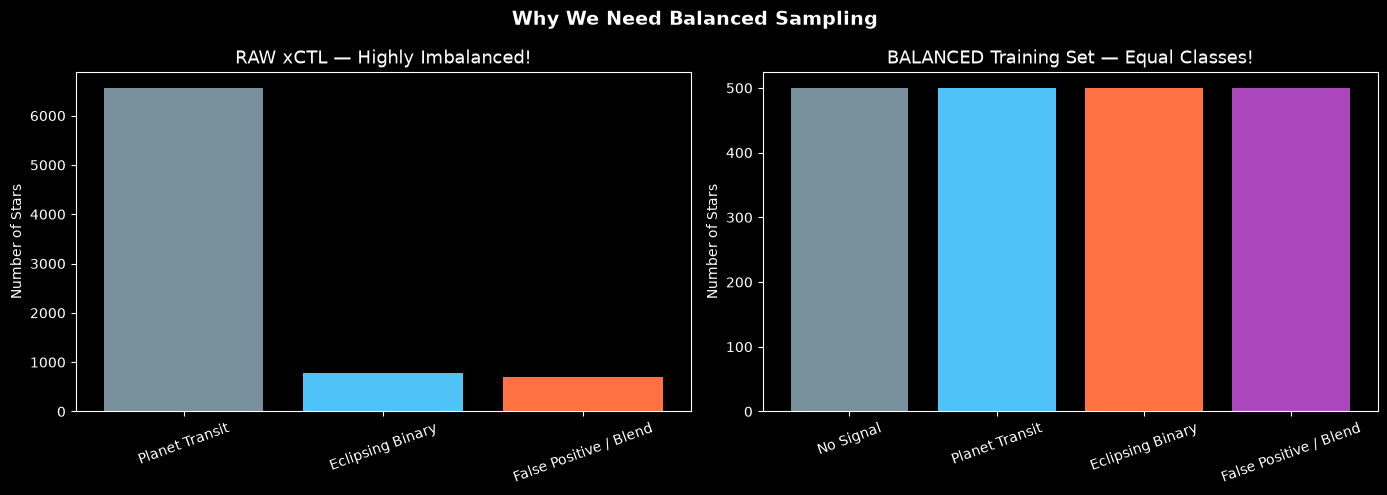

In [4]:
# ============================================================
# Visualise class imbalance
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

label_counts = df['label'].value_counts().sort_index()
colors = ['#78909C', '#4FC3F7', '#FF7043', '#AB47BC']

# Left: Raw imbalanced data
axes[0].bar(
    [LABEL_NAMES[i] for i in label_counts.index],
    label_counts.values,
    color=colors[:len(label_counts)]
)
axes[0].set_title('RAW xCTL — Highly Imbalanced!', fontsize=13)
axes[0].set_ylabel('Number of Stars')
axes[0].tick_params(axis='x', rotation=20)

# Right: After balanced sampling
balanced_counts = {name: 500 for name in [LABEL_NAMES[i] for i in [0,1,2,3]]}
axes[1].bar(balanced_counts.keys(), balanced_counts.values(), color=colors)
axes[1].set_title('BALANCED Training Set — Equal Classes!', fontsize=13)
axes[1].set_ylabel('Number of Stars')
axes[1].tick_params(axis='x', rotation=20)

plt.suptitle('Why We Need Balanced Sampling', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 3: Build Balanced Training Target List

We sample 500 stars from each of the 4 classes → **2,000 total training stars**


In [5]:
# Build our 2000-star balanced training set
targets = build_training_targets(df, n_per_class=500, seed=42)

print(f"Training target list shape: {targets.shape}")
print(f"\nFirst 5 targets:")
print(targets[['tic_id', 'label']].head())

# Check balance
print(f"\nFinal class distribution:")
for label, name in LABEL_NAMES.items():
    count = (targets['label'] == label).sum()
    print(f"  {label} — {name}: {count}")

2026-06-15 19:47:41,177 [INFO] Loading background stars from CTL to sample Class 0 (No Signal)...


2026-06-15 19:47:45,456 [INFO] Final balanced training targets list: 2000 stars
  Class 0 (No Signal): 500
  Class 1 (Planet Transit): 500
  Class 2 (Eclipsing Binary): 500
  Class 3 (False Positive / Blend): 500


2026-06-15 19:47:45,466 [INFO] Training targets saved to C:\Users\gudae\Desktop\Learn_ml\data\training_targets.csv


Training target list shape: (2000, 2)

First 5 targets:
      tic_id  label
0  165909881      0
1  122375047      1
2  155491828      3
3  134396419      2
4  376168473      3

Final class distribution:
  0 — No Signal: 500
  1 — Planet Transit: 500
  2 — Eclipsing Binary: 500
  3 — False Positive / Blend: 500


---
## 📚 Concept 3: Train / Validation / Test Split

Before downloading anything, we split our target list into three groups:

```
2000 stars total
├── Training set   (70% = 1400 stars) ← model LEARNS from this
├── Validation set (15% = 300 stars)  ← tune hyperparameters
└── Test set       (15% = 300 stars)  ← NEVER seen by model during training
                                         Used for final evaluation ONLY
```

**Why three splits?**  
- If we use the same data to train AND evaluate, the model just memorizes — **overfitting**.
- Validation set lets us tune the model without "cheating" on the test set.
- Test set is our honest, final estimate of real-world performance.

**Golden rule:** Never look at your test set until you've finalized your model!


In [6]:
from sklearn.model_selection import train_test_split

# First split: 85% train+val, 15% test
train_val, test = train_test_split(
    targets, test_size=0.15, random_state=42, stratify=targets['label']
)

# Second split: 70% train, 15% val  
train, val = train_test_split(
    train_val, test_size=0.176, random_state=42, stratify=train_val['label']
)

print(f"Training set:   {len(train):>5} stars")
print(f"Validation set: {len(val):>5} stars")
print(f"Test set:       {len(test):>5} stars")
print(f"Total:          {len(train)+len(val)+len(test):>5} stars")

# Save the splits
train.to_csv('../data/training_targets.csv', index=False)
val.to_csv('../data/validation_targets.csv', index=False)
test.to_csv('../data/test_targets.csv', index=False)

print("\n✅ Splits saved to data/ directory")

Training set:    1400 stars
Validation set:   300 stars
Test set:         300 stars
Total:           2000 stars

✅ Splits saved to data/ directory


---
## Step 4: Download Light Curves (batch)

> ⏱️ **Expected time:** 1–3 hours for 2000 light curves (depends on internet)  
> 💾 **Expected disk space:** ~2 GB  
> 🔁 Downloads are cached — if interrupted, re-running continues from where it stopped!

For now, let's start with just 20 to verify everything works:


In [7]:
# ============================================================
# Quick test: download 20 light curves first
# (5 from each class for a sanity check)
# ============================================================

QUICK_TEST = True  # Set to False to download ALL 2000 at once

if QUICK_TEST:
    # Sample 5 from each class
    quick_targets = pd.concat([
        train[train['label'] == i].head(5) for i in [0, 1, 2, 3]
    ], ignore_index=True)
    print(f"Quick test: downloading {len(quick_targets)} light curves...")
    result = batch_download(quick_targets, delay=0.5)
else:
    # Full download
    print(f"Full download: {len(train)} training light curves...")
    result = batch_download(train, delay=0.5)

success_rate = result['fits_path'].notna().mean()
print(f"\n✅ Success rate: {100*success_rate:.1f}%")
print(f"Files saved to: data/raw_fits/")

2026-06-15 19:47:46,070 [INFO] Downloading 20 light curves...


Quick test: downloading 20 light curves...


2026-06-15 19:47:49,621 [WARNING] TIC 214548381: no light curve found on MAST


2026-06-15 19:47:50,130 [INFO] TIC 1117953: already downloaded at C:\Users\gudae\Desktop\Learn_ml\data\raw_fits\mastDownload\TESS\tess2018292075959-s0004-0000000001117953-0124-s\tess2018292075959-s0004-0000000001117953-0124-s_lc.fits


2026-06-15 19:47:51,354 [WARNING] TIC 311266307: no light curve found on MAST


...

2026-06-15 19:48:00,271 [INFO] TIC 420112587: already downloaded at C:\Users\gudae\Desktop\Learn_ml\data\raw_fits\mastDownload\TESS\tess2019198215352-s0014-0000000420112587-0150-s\tess2019198215352-s0014-0000000420112587-0150-s_lc.fits


2026-06-15 19:48:00,779 [INFO] TIC 294173437: already downloaded at C:\Users\gudae\Desktop\Learn_ml\data\raw_fits\mastDownload\TESS\tess2024030031500-s0075-0000000294173437-0270-s\tess2024030031500-s0075-0000000294173437-0270-s_lc.fits


2026-06-15 19:48:01,287 [INFO] TIC 371210825: already downloaded at C:\Users\gudae\Desktop\Learn_ml\data\raw_fits\mastDownload\TESS\tess2021284114741-s0044-0000000371210825-0215-s\tess2021284114741-s0044-0000000371210825-0215-s_lc.fits



2026-06-15 19:48:01,789 [INFO] Download complete: 16/20 light curves fetched (80.0%)



✅ Success rate: 80.0%
Files saved to: data/raw_fits/


3% (405/15973) of the cadences will be ignored due to the quality mask (quality_bitmask=17087).


2026-06-15 19:48:01,998 [INFO] 3% (405/15973) of the cadences will be ignored due to the quality mask (quality_bitmask=17087).


2% (315/17861) of the cadences will be ignored due to the quality mask (quality_bitmask=17087).


2026-06-15 19:48:02,097 [INFO] 2% (315/17861) of the cadences will be ignored due to the quality mask (quality_bitmask=17087).


2% (410/17395) of the cadences will be ignored due to the quality mask (quality_bitmask=17087).


2026-06-15 19:48:02,205 [INFO] 2% (410/17395) of the cadences will be ignored due to the quality mask (quality_bitmask=17087).


1% (117/19550) of the cadences will be ignored due to the quality mask (quality_bitmask=17087).


2026-06-15 19:48:02,319 [INFO] 1% (117/19550) of the cadences will be ignored due to the quality mask (quality_bitmask=17087).


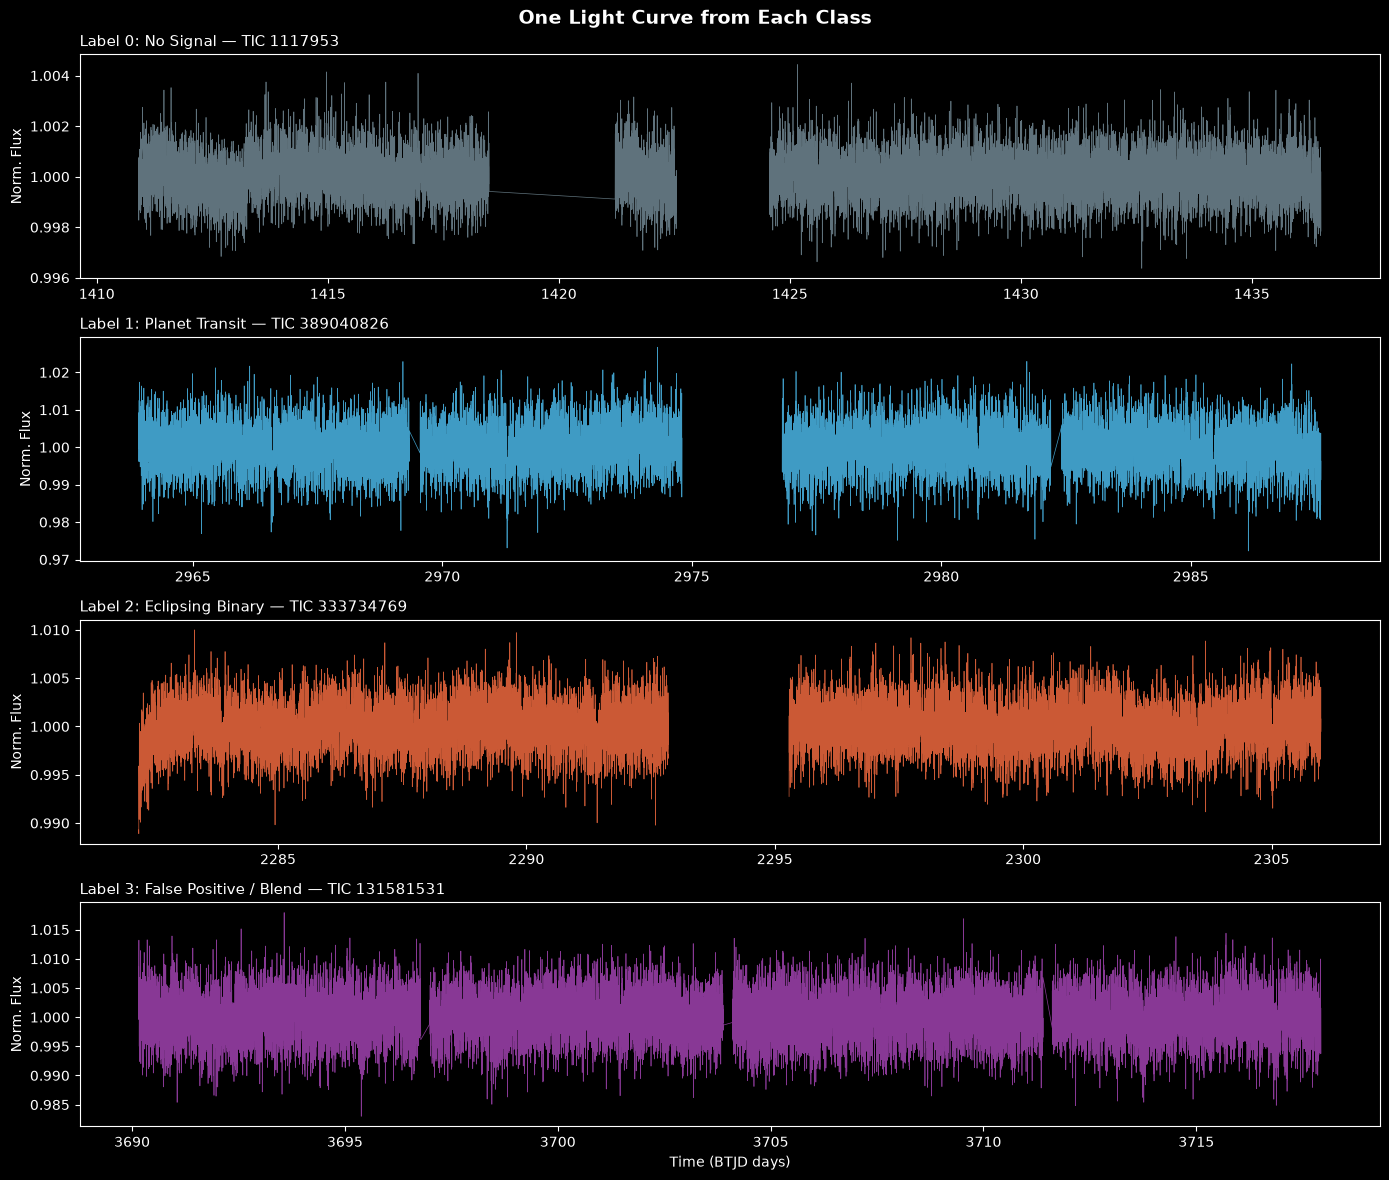

In [8]:
# ============================================================
# Visualise one light curve from each class
# ============================================================

import lightkurve as lk

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=False)
colors = ['#78909C', '#4FC3F7', '#FF7043', '#AB47BC']

for ax, label, color in zip(axes, [0, 1, 2, 3], colors):
    subset = result[result['label'] == label].dropna(subset=['fits_path'])
    if len(subset) == 0:
        ax.text(0.5, 0.5, f'No data downloaded for label {label}',
                ha='center', va='center', transform=ax.transAxes)
        continue
    
    row = subset.iloc[0]
    try:
        lc = lk.io.read(row['fits_path'])
        flux = lc.pdcsap_flux.value if hasattr(lc, 'pdcsap_flux') else lc.flux.value
        time = lc.time.value
        
        # Normalise
        flux = flux / np.nanmedian(flux)
        
        ax.plot(time, flux, lw=0.5, color=color, alpha=0.8)
        ax.set_title(f'Label {label}: {LABEL_NAMES[label]} — TIC {int(row["tic_id"])}',
                     fontsize=11, loc='left')
        ax.set_ylabel('Norm. Flux')
    except Exception as e:
        ax.text(0.5, 0.5, f'Error loading: {e}', ha='center', va='center',
                transform=ax.transAxes, color='red')

axes[-1].set_xlabel('Time (BTJD days)')
plt.suptitle('One Light Curve from Each Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/one_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

---
## ✅ Notebook 01 Summary

**ML concepts learned:**
- **API downloads**: programmatically fetching real NASA data
- **Class imbalance**: why raw data is biased and how to fix it
- **Train/val/test split**: the three-way split to prevent data leakage
- **Balanced sampling**: equal numbers per class for fair training
- **Rate limiting**: being a responsible API user

**Astronomy concepts learned:**
- xCTL disposition codes (CP, PC, EB, FP)
- Light curve structure (TIME, PDCSAP_FLUX, QUALITY)
- How different signal types look in raw data

**Next:** Notebook `02_preprocessing.ipynb` — cleaning the light curves for ML
